In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [26]:
# 데이터 로드
bank_df = pd.read_csv("../JeonJongHyeok/data/df_encoded_final.csv")
print(bank_df.head())

bank_df = bank_df.drop("trans_ct_bin", axis=1)

   churn  age  gender  dependents  relationship_months  product_count  \
0      1   45       0           3                   39              5   
1      1   49       1           5                   44              6   
2      1   51       0           3                   36              4   
3      1   40       1           4                   34              3   
4      1   40       0           3                   21              5   

   inactive_months  contact_count  credit_limit  revolving_balance  ...  \
0                1              3       12691.0                777  ...   
1                1              2        8256.0                864  ...   
2                1              0        3418.0                  0  ...   
3                4              1        3313.0               2517  ...   
4                1              0        4716.0                  0  ...   

   income_1  income_2  income_3  income_4  income_5  income_Income_Unknown  \
0     False     False      True 

In [27]:
cols = [k for k in bank_df.columns if k.startswith("income_")]
print(bank_df.columns)
print(cols)

Index(['churn', 'age', 'gender', 'dependents', 'relationship_months',
       'product_count', 'inactive_months', 'contact_count', 'credit_limit',
       'revolving_balance', 'available_credit', 'amount_change',
       'transaction_amount', 'transaction_count', 'count_change',
       'utilization_ratio', 'amt_per_it', 'education_1', 'education_2',
       'education_3', 'education_4', 'education_5', 'education_6',
       'education_Education_Unknown', 'marital_1', 'marital_2', 'marital_3',
       'marital_Marital_Unknown', 'income_1', 'income_2', 'income_3',
       'income_4', 'income_5', 'income_Income_Unknown', 'card_type_1',
       'card_type_2', 'card_type_3', 'card_type_4'],
      dtype='str')
['income_1', 'income_2', 'income_3', 'income_4', 'income_5', 'income_Income_Unknown']


In [28]:
def prep_income(instr):
    arr = ['1', '2', '3', '4', '5', 'Income_Unknown']
    return arr.index(instr) + 1

bank_df["income"] = (
    bank_df[cols]
    .idxmax(axis=1)
    .str.replace("income_", "")
)

bank_df = bank_df.drop(cols, axis=1)

bank_df["income"] = bank_df["income"].apply(prep_income)

In [29]:
bank_df["income"].value_counts()

income
1    3561
2    1790
4    1535
3    1402
6    1112
5     727
Name: count, dtype: int64

In [ ]:
# features = [k for k in bank_df.columns if k != "income"]
# features = ["revolving_balance", "transaction_count", "count_change"]
features = ["credit_limit", "available_credit", "utilization_ratio"]
features_df = bank_df[features]
income_df = bank_df['income']

print(features_df.describe())
print(income_df.value_counts())

              churn           age        gender    dependents  \
count  10127.000000  10127.000000  10127.000000  10127.000000   
mean       0.839340     46.325960      0.529081      2.346203   
std        0.367235      8.016814      0.499178      1.298908   
min        0.000000     26.000000      0.000000      0.000000   
25%        1.000000     41.000000      0.000000      1.000000   
50%        1.000000     46.000000      1.000000      2.000000   
75%        1.000000     52.000000      1.000000      3.000000   
max        1.000000     73.000000      1.000000      5.000000   

       relationship_months  product_count  inactive_months  contact_count  \
count         10127.000000   10127.000000     10127.000000   10127.000000   
mean             35.928409       3.812580         2.341167       2.455317   
std               7.986416       1.554408         1.010622       1.106225   
min              13.000000       1.000000         0.000000       0.000000   
25%              31.000000   

In [31]:
features_known_df = features_df[income_df != 6]
features_unknown_df = features_df[income_df == 6]
income_known_df = income_df[income_df != 6]
income_unknown_df = income_df[income_df == 6]

print(features_known_df.describe())
print(income_known_df.value_counts())

             churn          age       gender   dependents  \
count  9015.000000  9015.000000  9015.000000  9015.000000   
mean      0.840266    46.332335     0.476761     2.354964   
std       0.366379     7.933915     0.499487     1.295146   
min       0.000000    26.000000     0.000000     0.000000   
25%       1.000000    41.000000     0.000000     1.000000   
50%       1.000000    46.000000     0.000000     2.000000   
75%       1.000000    52.000000     1.000000     3.000000   
max       1.000000    73.000000     1.000000     5.000000   

       relationship_months  product_count  inactive_months  contact_count  \
count          9015.000000    9015.000000      9015.000000    9015.000000   
mean             35.949972       3.812313         2.337105       2.454465   
std               7.923702       1.556154         1.005561       1.107845   
min              13.000000       1.000000         0.000000       0.000000   
25%              32.000000       3.000000         2.000000       

In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
features_known_df_scaled = scaler.fit_transform(features_known_df)
features_unknown_df_scaled = scaler.transform(features_unknown_df)

In [33]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis(n_components=2)
features_known_df_lda = lda.fit_transform(features_known_df_scaled, income_known_df)
features_unknown_df_lda = lda.transform(features_unknown_df_scaled)

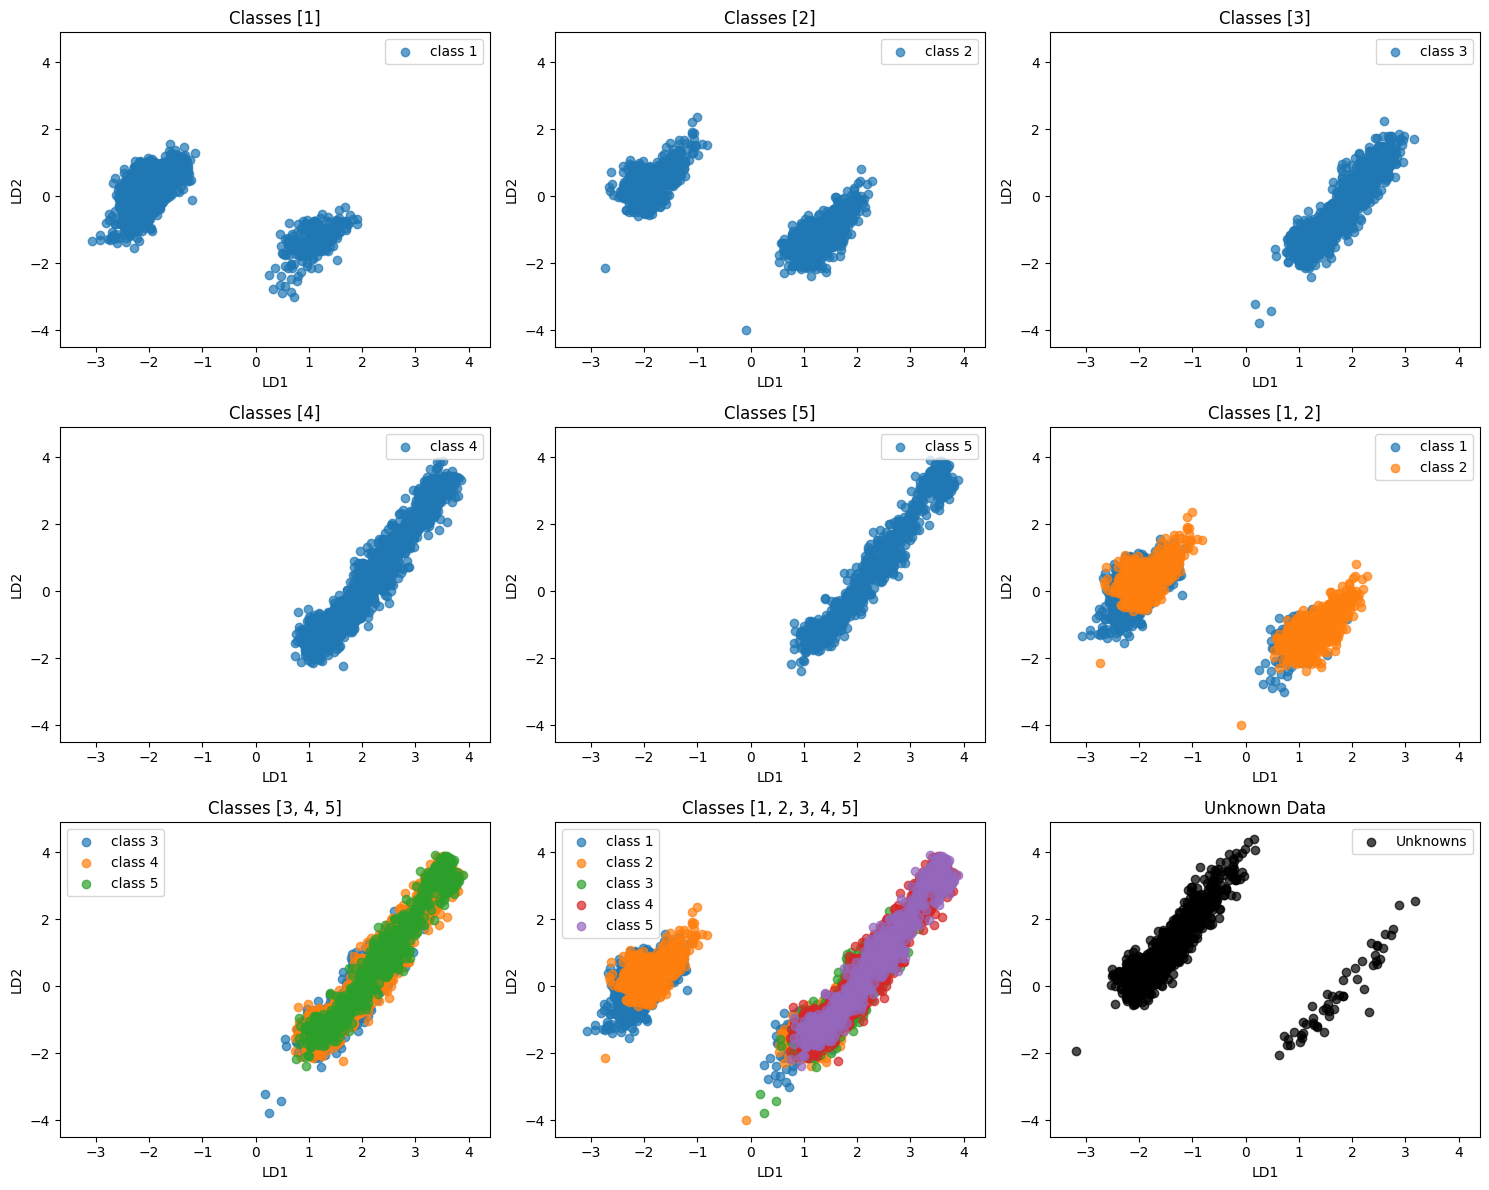

In [34]:
import matplotlib.pyplot as plt
import numpy as np

groups = [
    [1],
    [2],
    [3],
    [4],
    [5],
    [1,2],
    [3,4,5],
    [1,2,3,4,5]
]

# 전체 데이터 범위 계산
all_x = np.concatenate([features_known_df_lda[:,0], features_unknown_df_lda[:,0]])
all_y = np.concatenate([features_known_df_lda[:,1], features_unknown_df_lda[:,1]])

margin = 0.5
xlim = (all_x.min()-margin, all_x.max()+margin)
ylim = (all_y.min()-margin, all_y.max()+margin)

fig, axes = plt.subplots(3,3, figsize=(15,12))
axes = axes.flatten()

# 클래스 데이터 subplot
for ax, group in zip(axes[:8], groups):

    for c in group:
        ax.scatter(
            features_known_df_lda[income_known_df==c,0],
            features_known_df_lda[income_known_df==c,1],
            label=f"class {c}",
            alpha=0.7
        )

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_title(f"Classes {group}")
    ax.set_xlabel("LD1")
    ax.set_ylabel("LD2")
    ax.legend()

# Unknown subplot
ax = axes[8]
ax.scatter(
    features_unknown_df_lda[:,0],
    features_unknown_df_lda[:,1],
    label="Unknowns",
    color="black",
    alpha=0.7
)

ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_title("Unknown Data")
ax.set_xlabel("LD1")
ax.set_ylabel("LD2")
ax.legend()

plt.tight_layout()
plt.show()

In [35]:
from sklearn.model_selection import train_test_split

#y_data = income_known_df
y_data = np.where(income_known_df <= 2, 0, 1)

train_X, test_X, train_y, test_y = train_test_split(
    features_known_df_scaled,
    y_data,
    stratify=y_data,
    random_state=42,
    test_size=0.2
)

In [36]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(train_X, train_y)

print(lr.score(train_X, train_y))
print(lr.score(test_X, test_y))

0.8950360510260676
0.8935108153078203


In [37]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(random_state=42, max_depth=3)
rf_clf.fit(train_X, train_y)

print(rf_clf.score(train_X, train_y))
print(rf_clf.score(test_X, test_y))

0.8279256794231836
0.8325013865779257


In [38]:
def print_valcnt(arr):
    values, counts = np.unique(arr, return_counts=True)

    print("values :", " ".join(f"{v:>5}" for v in values))
    print("counts :", " ".join(f"{c:>5}" for c in counts))

In [39]:
lr_predicted = lr.predict(features_unknown_df_scaled)
rf_clf_predicted = rf_clf.predict(features_unknown_df_scaled)

print("===== 각 모델 예측된 클래스 수 =====")
print("LinearRegressor")
print_valcnt(lr_predicted)
print()
print("RandomForestClassifier")
print_valcnt(rf_clf_predicted)

print()

print("===== 서로 다르게 예측된 데이터들 ======")
print(f"다르게 예측된 데이터 수: {(lr_predicted != rf_clf_predicted).sum()}/{len(lr_predicted)}")
print(lr_predicted[(lr_predicted != rf_clf_predicted)])
print(rf_clf_predicted[(lr_predicted != rf_clf_predicted)])

===== 각 모델 예측된 클래스 수 =====
LinearRegressor
values :     0     1
counts :  1069    43

RandomForestClassifier
values :     0     1
counts :  1072    40

===== 서로 다르게 예측된 데이터들 ======
다르게 예측된 데이터 수: 21/1112
[1 1 1 1 1 1 1 1 1 1 1 0 0 0 1 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 1 1 1 1 1 1]
